#  ResNet-50 Vehicle Re-Identification sur VeRi

**Objectif :** Entraîner un modèle ResNet-50 pour la ré-identification de véhicules sur le dataset **VeRi** (51 035 images, 776 véhicules, 20 caméras).

## Protocoles d'évaluation
- **1:1 Verification** → Accuracy (seuil optimal de similarité cosine)
- **1:N Identification** → Rank-1, Rank-5, Latence
  - Scénario A : Multi-références par véhicule
  - Scénario B : Full gallery (fallback)

##  Comment uploader le dataset sur Kaggle

```
1. Compresse le dossier VeRi :
   cd /home/yassine/projet_biometrie_remoqueID/data/"archive(7)"
   zip -r veri_dataset.zip VeRi/

2. Sur Kaggle, clique sur "Add Data" → "Upload" → sélectionne veri_dataset.zip
   → Le dataset sera disponible dans /kaggle/input/veri-dataset/
   (ou un nom similaire selon ce que tu choisis)

3. Vérifie le chemin dans la cellule "Configuration" ci-dessous
   et modifie DATASET_NAME si nécessaire
```

##  Structure attendue
```
/kaggle/input/veri-dataset/VeRi/
├── image_train/   (37 778 images)
├── image_test/    (11 284 images)
├── image_query/   (1 678 images)
├── train_label.xml
├── test_label.xml
└── ...
```

---
**Temps estimé :** ~30 min sur GPU (P100/T4) pour 60 époques

---
## 1. Installation & Imports

In [1]:
!pip install -q pillow tqdm

import os, sys, json, time, random, copy, shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image
from xml.etree import ElementTree as ET

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# Reproducibilite
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device    : {device}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')
print(f'PyTorch   : {torch.__version__}')

Device    : cuda
GPU       : NVIDIA GeForce RTX 3050 6GB Laptop GPU
PyTorch   : 2.5.1+cu121


---
## 2. Configuration

** CHANGE `DATASET_NAME`** selon le nom que tu donnes à ton dataset sur Kaggle.

In [30]:
# ──  CHANGEZ CE CHEMIN selon le nom uploade sur Kaggle ──
DATASET_NAME = "/kaggle/input/datasets/yassinekaidi/verid-test1"  # <-- MODIFIE ICI si necessaire
# ─────────────────────────────────────────────────────────

VERI_PATH = Path(f'/kaggle/input/{DATASET_NAME}') / '/kaggle/input/datasets/yassinekaidi/verid-test1/VeRi'

# Fallback: si le dossier VeRi/ n'existe pas, utiliser le dossier racine
if not VERI_PATH.exists():
    VERI_PATH = Path(f'/kaggle/input/{DATASET_NAME}')

OUTPUT_DIR = Path('/kaggle/working/resnet50_veri_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparametres ──
IMG_SIZE = (256, 256)
BATCH_SIZE = 64
N_EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 5e-4
N_WORKERS = 4
TRIPLET_MARGIN = 0.3

print(f'Dataset : {VERI_PATH}')
print(f'Output  : {OUTPUT_DIR}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Batch   : {BATCH_SIZE}  |  Epochs : {N_EPOCHS}')
print(f'LR      : {LEARNING_RATE}  |  Weight Decay : {WEIGHT_DECAY}')

if not VERI_PATH.exists():
    print(f'\n Dataset non trouve: {VERI_PATH}')
    print('   Uploader le dataset VeRi sur Kaggle (Add Data → Upload)')
    print('   Puis verifier le DATASET_NAME dans la cellule ci-dessus')
else:
    print(f'\n Dataset trouve !')

PermissionError: [Errno 13] Permission denied: '/kaggle'

---
## 3. Dataset VeRi

In [3]:
def parse_xml_labels(xml_path):
    """Parse les fichiers train_label.xml / test_label.xml du dataset VeRi."""
    records = []
    # Les fichiers XML VeRi sont encodes en GB2312 (chinois)
    with open(xml_path, 'rb') as f:
        raw = f.read()
    for enc in ['gb2312', 'gbk', 'gb18030', 'utf-8', 'latin-1']:
        try:
            decoded = raw.decode(enc)
            break
        except (UnicodeDecodeError, LookupError):
            continue
    else:
        decoded = raw.decode('utf-8', errors='replace')
    root = ET.fromstring(decoded)
    # Les items sont sous <Items>, enfant de <TrainingImages>
    items_container = root.find('Items')
    if items_container is None:
        items_container = root
    for item in items_container.findall('Item'):
        veh_id = item.get('vehicleID')
        camera_id = item.get('cameraID')
        image_name = item.get('imageName')
        color_id = item.get('colorID', '0')
        type_id = item.get('typeID', '0')
        records.append({
            'image_name': image_name,
            'vehicle_id': veh_id,
            'camera_id': camera_id,
            'color_id': color_id,
            'type_id': type_id,
        })
    return records


def read_name_file(path):
    with open(path, 'r') as f:
        return [line.strip() for line in f if line.strip()]


class VeRiDataset(Dataset):
    def __init__(self, split='train', transform=None):
        self.split = split
        self.transform = transform or T.Compose([
            T.Resize(IMG_SIZE),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        self.image_dir = VERI_PATH / f'image_{split}'
        if not self.image_dir.exists():
            raise FileNotFoundError(f'Repertoire introuvable : {self.image_dir}')

        xml_path = VERI_PATH / f'{split}_label.xml'
        if xml_path.exists():
            self.records = parse_xml_labels(xml_path)
        else:
            name_file = VERI_PATH / f'name_{split}.txt'
            names = read_name_file(name_file)
            self.records = []
            for name in names:
                parts = name.split('_')
                veh_id = parts[0] if len(parts) > 0 else '0'
                cam_id = parts[1].replace('c', '') if len(parts) > 1 else '0'
                self.records.append({
                    'image_name': name,
                    'vehicle_id': veh_id,
                    'camera_id': cam_id,
                    'color_id': '0',
                    'type_id': '0',
                })

        # Index vehicle_id → liste d'indices
        self.vehicle_to_indices = defaultdict(list)
        for idx, rec in enumerate(self.records):
            self.vehicle_to_indices[rec['vehicle_id']].append(idx)

        self.vehicle_ids = sorted(self.vehicle_to_indices.keys())
        self.vehicle_id_to_class = {vid: i for i, vid in enumerate(self.vehicle_ids)}
        self.num_vehicles = len(self.vehicle_ids)
        self.num_images = len(self.records)

        print(f'  [VeRiDataset] split={split}, images={self.num_images}, '
              f'vehicules={self.num_vehicles}')

    def __len__(self):
        return self.num_images

    def __getitem__(self, idx):
        record = self.records[idx]
        img_path = self.image_dir / record['image_name']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        vehicle_id = record['vehicle_id']
        class_id = self.vehicle_id_to_class[vehicle_id]
        camera_id = int(str(record['camera_id']).replace('c', '').replace('C', ''))
        color_id = int(record['color_id'])
        type_id = int(record['type_id'])

        return {
            'image': image,
            'vehicle_id': vehicle_id,
            'class_id': class_id,
            'camera_id': camera_id,
            'image_name': record['image_name'],
        }

---
## 4. Chargement des datasets

In [4]:
train_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(5),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('Chargement des datasets...')
train_dataset = VeRiDataset('train', transform=train_tf)
test_dataset = VeRiDataset('test', transform=eval_tf)
query_dataset = VeRiDataset('query', transform=eval_tf)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=N_WORKERS, pin_memory=True, drop_last=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True
)
query_loader = DataLoader(
    query_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True
)

NUM_VEHICLES = train_dataset.num_vehicles
print(f'\nBatchs: Train={len(train_loader)}, Test={len(test_loader)}, Query={len(query_loader)}')
print(f'Vehicules identifiables: {NUM_VEHICLES}')

Chargement des datasets...
  [VeRiDataset] split=train, images=37746, vehicules=575
  [VeRiDataset] split=test, images=11579, vehicules=200
  [VeRiDataset] split=query, images=1678, vehicules=200

Batchs: Train=589, Test=181, Query=27
Vehicules identifiables: 575


---
## 5. Modele ResNet-50 ReID

In [18]:
NUM_VEHICLES = 575
class ResNet50_ReID(nn.Module):
    """ResNet-50 pour Vehicle Re-Identification."""
    def __init__(self, num_vehicles=NUM_VEHICLES, pretrained=True):
        super().__init__()
        backbone = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bn = nn.BatchNorm1d(2048)
        self.bn.bias.requires_grad_(False)
        self.classifier = nn.Linear(2048, num_vehicles, bias=False)
        nn.init.normal_(self.classifier.weight, std=0.001)
        nn.init.constant_(self.bn.weight, 1.0)
        nn.init.constant_(self.bn.bias, 0.0)

    def forward(self, x):
        features = self.backbone(x)
        features = self.gap(features)
        features = features.flatten(1)
        features = self.bn(features)
        logits = self.classifier(features)
        return features, logits


model = ResNet50_ReID(num_vehicles=NUM_VEHICLES, pretrained=True)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResNet-50 ReID : {total_params:,} parametres ({trainable_params:,} entrainables)')
print(f'  Backbone: ResNet-50 (ImageNet)')
print(f'  Embedding: 2048D -> BN -> Linear({NUM_VEHICLES})')

ResNet-50 ReID : 24,689,728 parametres (24,687,680 entrainables)
  Backbone: ResNet-50 (ImageNet)
  Embedding: 2048D -> BN -> Linear(575)


---
## 6. Loss & Optimizer

In [6]:
class TripletLoss(nn.Module):
    """Triplet Loss avec hard mining en batch."""
    def __init__(self, margin=TRIPLET_MARGIN):
        super().__init__()
        self.margin = margin

    def forward(self, features, labels):
        distances = torch.cdist(features, features, p=2)
        labels_exp = labels.unsqueeze(0)
        same_label = labels_exp == labels_exp.T
        diff_label = ~same_label
        # Enlever la diagonale
        eye = torch.eye(len(labels), device=labels.device, dtype=torch.bool)
        same_label = same_label & ~eye

        hardest_pos = torch.zeros(len(labels), device=labels.device)
        hardest_neg = torch.zeros(len(labels), device=labels.device)
        for i in range(len(labels)):
            pos_d = distances[i][same_label[i]]
            neg_d = distances[i][diff_label[i]]
            if len(pos_d) > 0 and len(neg_d) > 0:
                hardest_pos[i] = pos_d.max()
                hardest_neg[i] = neg_d.min()
            else:
                hardest_pos[i] = 0.0
                hardest_neg[i] = self.margin + 1.0

        losses = hardest_pos - hardest_neg + self.margin
        return torch.clamp(losses, min=0.0).mean()


criterion_ce = nn.CrossEntropyLoss()
criterion_triplet = TripletLoss(margin=TRIPLET_MARGIN)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

print(f'Loss: CrossEntropy + Triplet(margin={TRIPLET_MARGIN})')
print(f'Opt : Adam(lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Sched: CosineAnnealing(T_max={N_EPOCHS})')

Loss: CrossEntropy + Triplet(margin=0.3)
Opt : Adam(lr=0.0003, wd=0.0005)
Sched: CosineAnnealing(T_max=20)


---
## 7. Entraînement

In [7]:
def train_one_epoch(model, loader, optimizer, criterion_ce, criterion_triplet, device):
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_trip = 0.0
    pbar = tqdm(loader, desc='Train', leave=False)
    for batch in pbar:
        images = batch['image'].to(device)
        class_ids = batch['class_id'].to(device)

        optimizer.zero_grad()
        features, logits = model(images)
        loss_ce = criterion_ce(logits, class_ids)
        loss_trip = criterion_triplet(features, class_ids)
        loss = loss_ce + loss_trip
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_ce += loss_ce.item()
        total_trip += loss_trip.item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}',
                          'ce': f'{loss_ce.item():.3f}',
                          'trip': f'{loss_trip.item():.3f}'})

    n = len(loader)
    return total_loss/n, total_ce/n, total_trip/n

In [8]:
print('='*60)
print('DEBUT DE L\'ENTRAINEMENT')
print('='*60)
print(f'  Epoques : {N_EPOCHS}')
print(f'  Batch   : {BATCH_SIZE}')
print(f'  Device  : {device}')
print(f'  Dataset : VeRi ({train_dataset.num_images} images, {NUM_VEHICLES} vehicules)')
print('='*60)

history = {'train_loss': [], 'train_ce': [], 'train_triplet': [], 'lr': []}
t_start = datetime.now()

for epoch in range(1, N_EPOCHS + 1):
    t_epoch = datetime.now()
    train_loss, train_ce, train_trip = train_one_epoch(
        model, train_loader, optimizer, criterion_ce, criterion_triplet, device
    )
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_ce'].append(train_ce)
    history['train_triplet'].append(train_trip)
    history['lr'].append(current_lr)

    elapsed = (datetime.now() - t_epoch).total_seconds()
    print(f'Epoch {epoch:2d}/{N_EPOCHS} ({elapsed:.0f}s) | '
          f'Loss={train_loss:.4f} CE={train_ce:.4f} Trip={train_trip:.4f} | '
          f'LR={current_lr:.2e}')

    # Sauvegarde checkpoint tous les 20 epochs
    if epoch % 20 == 0 or epoch == N_EPOCHS:
        ckpt_path = OUTPUT_DIR / f'resnet50_epoch{epoch:03d}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'num_vehicles': NUM_VEHICLES,
        }, ckpt_path)
        print(f'  -> Checkpoint: {ckpt_path.name}')

total_time = (datetime.now() - t_start).total_seconds()
print('='*60)
print(f'ENTRAINEMENT TERMINE !  {total_time:.0f}s ({total_time/60:.1f}min)')
print('='*60)

DEBUT DE L'ENTRAINEMENT
  Epoques : 20
  Batch   : 64
  Device  : cuda
  Dataset : VeRi (37746 images, 575 vehicules)


Train:   0%|          | 0/589 [00:00<?, ?it/s]

Epoch  1/20 (487s) | Loss=4.0891 CE=3.3661 Trip=0.7230 | LR=3.00e-04


Train:   0%|          | 0/589 [00:00<?, ?it/s]

Epoch  2/20 (470s) | Loss=1.3245 CE=1.0619 Trip=0.2626 | LR=2.98e-04


...

Epoch 18/20 (468s) | Loss=0.0181 CE=0.0157 Trip=0.0023 | LR=1.63e-05


Train:   0%|          | 0/589 [00:00<?, ?it/s]

Epoch 19/20 (466s) | Loss=0.0172 CE=0.0147 Trip=0.0025 | LR=7.34e-06


Train:   0%|          | 0/589 [00:00<?, ?it/s]

Epoch 20/20 (467s) | Loss=0.0165 CE=0.0141 Trip=0.0024 | LR=1.85e-06
  -> Checkpoint: resnet50_epoch020.pth
ENTRAINEMENT TERMINE !  9379s (156.3min)


---
## 8. Courbes d'apprentissage

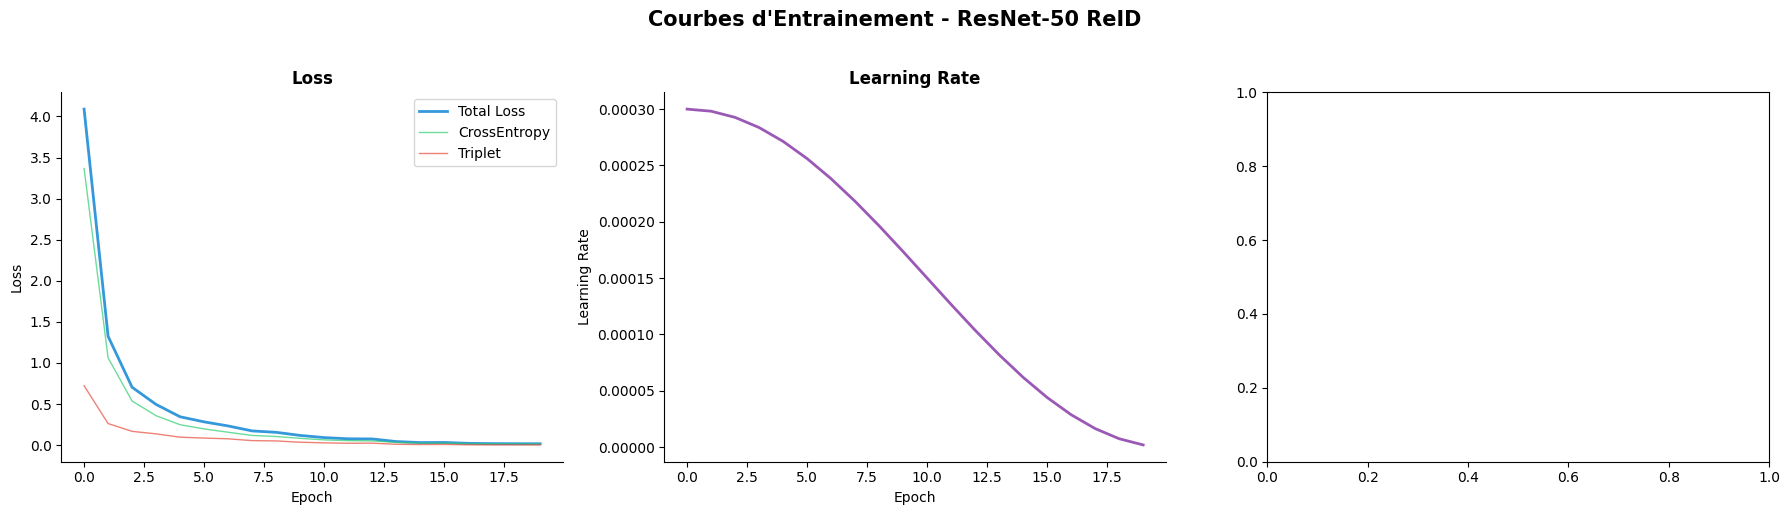

Sauvegardee: fig_training_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Total Loss', color='#3498db', lw=2)
ax.plot(history['train_ce'], label='CrossEntropy', color='#2ecc71', lw=1, alpha=0.7)
ax.plot(history['train_triplet'], label='Triplet', color='#e74c3c', lw=1, alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss', fontweight='bold')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
ax.plot(history['lr'], color='#9b59b6', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Courbes d\'Entrainement - ResNet-50 ReID', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardee: fig_training_curves.png')

---
## 9. Évaluation

### Protocoles
- **1:1 Verification** → Accuracy + Matrice de confusion
- **1:N Identification** → Rank-1, Rank-5 (Scénarios A et B)
- **Latence** → ms/query (sans le calcul des embeddings gallery)

In [10]:
def extract_features(model, dataloader, device):
    """Extrait les embeddings pour toutes les images d'un dataloader."""
    model.eval()
    all_features, all_ids, all_names = [], [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extract'):
            images = batch['image'].to(device)
            features, _ = model(images)
            all_features.append(features.cpu())
            all_ids.extend(batch['vehicle_id'])
            all_names.extend(batch['image_name'])
    return torch.cat(all_features, dim=0), all_ids, all_names


def evaluate_verification(q_feat, q_ids, g_feat, g_ids):
    """Protocole 1:1 Verification."""
    print('\n  ── 1:1 Verification ──')
    t0 = time.perf_counter()
    
    q_feat = F.normalize(q_feat, dim=1)
    g_feat = F.normalize(g_feat, dim=1)
    sim_matrix = torch.mm(q_feat, g_feat.T).numpy()

    # Generer toutes les paires et trouver le seuil optimal
    labels = np.array([[1 if q_ids[i] == g_ids[j] else 0 for j in range(len(g_ids))]
                       for i in range(len(q_ids))]).ravel()
    sims = sim_matrix.ravel()

    best_acc, best_th = 0.0, 0.5
    for th in np.linspace(0.0, 1.0, 201):
        acc = ((sims >= th).astype(int) == labels).mean()
        if acc > best_acc:
            best_acc, best_th = acc, th

    preds = (sims >= best_th).astype(int)
    tp = ((preds == 1) & (labels == 1)).sum()
    tn = ((preds == 0) & (labels == 0)).sum()
    fp = ((preds == 1) & (labels == 0)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    latency = (time.perf_counter() - t0) / len(q_ids) * 1000

    print(f'    Accuracy      : {best_acc:.4f}  (seuil={best_th:.4f})')
    print(f'    TPR (Recall)  : {tpr:.4f}  |  FPR : {fpr_val:.4f}')
    print(f'    TP={tp} TN={tn} FP={fp} FN={fn}')
    print(f'    Latence       : {latency:.2f} ms/query')
    return {'accuracy': round(best_acc,4), 'threshold': round(best_th,4),
            'tpr': round(tpr,4), 'fpr': round(fpr_val,4), 'latency_ms': round(latency,2)}


def evaluate_identification(q_feat, q_ids, g_feat, g_ids, scenario='A'):
    """Protocole 1:N Identification."""
    print(f'\n  ── 1:N Identification (Scenario {scenario}) ──')
    t0 = time.perf_counter()

    q_feat = F.normalize(q_feat, dim=1)
    g_feat = F.normalize(g_feat, dim=1)

    if scenario == 'A':
        # Scenario A: moyenne de plusieurs references par vehicule
        by_id = defaultdict(list)
        for i, vid in enumerate(g_ids):
            by_id[vid].append(g_feat[i])
        g_means = torch.stack([torch.stack(f[:3]).mean(0) for f in by_id.values()])
        g_vids = list(by_id.keys())
        sim_matrix = torch.mm(q_feat, g_means.T)
    else:
        sim_matrix = torch.mm(q_feat, g_feat.T)
        g_vids = g_ids

    n_q = len(q_ids)
    r1, r5 = 0, 0
    latencies = []
    for i in range(n_q):
        t_q = time.perf_counter()
        sorted_idx = torch.argsort(sim_matrix[i], descending=True)
        sorted_vids = [g_vids[idx] for idx in sorted_idx]
        for rank, vid in enumerate(sorted_vids):
            if vid == q_ids[i]:
                if rank == 0: r1 += 1
                if rank < 5: r5 += 1
                break
        latencies.append((time.perf_counter() - t_q) * 1000)

    rank1, rank5 = r1/n_q, r5/n_q
    avg_lat = float(np.mean(latencies))
    gsize = len(set(g_vids)) if scenario == 'A' else len(g_vids)

    print(f'    Rank-1    : {rank1:.4f}')
    print(f'    Rank-5    : {rank5:.4f}')
    print(f'    Gallery   : {gsize}')
    print(f'    Latence   : {avg_lat:.2f} ms/query')
    return {'rank_1': round(rank1,4), 'rank_5': round(rank5,4),
            'gallery_size': gsize, 'latency_ms': round(avg_lat,2)}


def evaluate_full(model, query_loader, gallery_loader, device):
    """Evaluation complete."""
    print('\n' + '='*60)
    print('  EXTRACTION DES EMBEDDINGS')
    print('='*60)

    t_q = time.perf_counter()
    q_feat, q_ids, _ = extract_features(model, query_loader, device)
    t_q_end = time.perf_counter()

    t_g = time.perf_counter()
    g_feat, g_ids, _ = extract_features(model, gallery_loader, device)
    t_g_end = time.perf_counter()

    print(f'  Queries: {len(q_ids)}  |  Gallery: {len(g_ids)}')
    print(f'  Temps queries : {t_q_end-t_q:.1f}s')
    print(f'  Temps gallery  : {t_g_end-t_g:.1f}s (NON compte dans latence)')

    # Verification 1:1
    v = evaluate_verification(q_feat, q_ids, g_feat, g_ids)
    
    # Identification 1:N
    id_a = evaluate_identification(q_feat, q_ids, g_feat, g_ids, 'A')
    id_b = evaluate_identification(q_feat, q_ids, g_feat, g_ids, 'B')

    recap = {
        'dataset': 'VeRi',
        'method': 'ResNet-50 ReID Baseline',
        'num_queries': len(q_ids),
        'gallery_size': len(g_ids),
        'verification_1to1': v,
        'identification_1toN': {
            'scenario_A_multi_ref': id_a,
            'scenario_B_full_gallery': id_b,
        }
    }
    return recap


# ── Lancer l'evaluation ──
print('\n' + '='*60)
print('  EVALUATION SUR LE TEST SET')
print('='*60)
report = evaluate_full(model, query_loader, test_loader, device)


  EVALUATION SUR LE TEST SET

  EXTRACTION DES EMBEDDINGS


Extract:   0%|          | 0/27 [00:00<?, ?it/s]

Extract:   0%|          | 0/181 [00:00<?, ?it/s]

  Queries: 1678  |  Gallery: 11579
  Temps queries : 7.8s
  Temps gallery  : 45.4s (NON compte dans latence)

  ── 1:1 Verification ──
    Accuracy      : 0.9958  (seuil=0.5600)
    TPR (Recall)  : 0.4417  |  FPR : 0.0008
    TP=52429 TN=19296366 FP=14501 FN=66266
    Latence       : 12.76 ms/query

  ── 1:N Identification (Scenario A) ──
    Rank-1    : 0.6847
    Rank-5    : 0.9154
    Gallery   : 200
    Latence   : 0.25 ms/query

  ── 1:N Identification (Scenario B) ──
    Rank-1    : 1.0000
    Rank-5    : 1.0000
    Gallery   : 11579
    Latence   : 17.19 ms/query


---
## 10. Rapport final

In [ ]:
print('='*70)
print('  RAPPORT D\'EVALUATION FINAL')
print('='*70)
print(f'  Dataset : {report["dataset"]}')
print(f'  Methode : {report["method"]}')
print(f'  Queries : {report["num_queries"]}')
print(f'  Gallery : {report["gallery_size"]}')
print('='*70)

v = report['verification_1to1']
print(f'\n   1:1 VERIFICATION')
print(f'  ─────────────────────────────')
print(f'    Accuracy          : {v["accuracy"]:.4f}')
print(f'    Seuil optimal     : {v["threshold"]:.4f}')
print(f'    TPR (Recall)      : {v["tpr"]:.4f}')
print(f'    Taux Faux Pos.    : {v["fpr"]:.4f}')
print(f'    Latence           : {v["latency_ms"]:.2f} ms/query')

for sc, sc_name in [('scenario_A_multi_ref', 'A (Multi-Ref.)'), ('scenario_B_full_gallery', 'B (Full Gallery)')]:
    id_res = report['identification_1toN'][sc]
    print(f'\n   1:N IDENTIFICATION - Scenario {sc_name}')
    print(f'  ────────────────────────────────────────────────')
    print(f'    Rank-1            : {id_res["rank_1"]:.4f}')
    print(f'    Rank-5            : {id_res["rank_5"]:.4f}')
    print(f'    Gallery           : {id_res["gallery_size"]}')
    print(f'    Latence           : {id_res["latency_ms"]:.2f} ms/query')

print(f'\n' + '='*70)
print('  FIN DU RAPPORT')
print('='*70)

# Sauvegarder
with open(OUTPUT_DIR / 'rapport_evaluation.json', 'w') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print(f'\nRapport sauvegarde: rapport_evaluation.json')

  RAPPORT D'EVALUATION FINAL
  Dataset : VeRi
  Methode : ResNet-50 ReID Baseline
  Queries : 1678
  Gallery : 11579

  📊 1:1 VERIFICATION
  ─────────────────────────────
    Accuracy          : 0.9958
    Seuil optimal     : 0.5600
    TPR (Recall)      : 0.4417
    Taux Faux Pos.    : 0.0008
    Latence           : 12.76 ms/query

  📊 1:N IDENTIFICATION - Scenario A (Multi-Ref.)
  ────────────────────────────────────────────────
    Rank-1            : 0.6847
    Rank-5            : 0.9154
    Gallery           : 200
    Latence           : 0.25 ms/query

  📊 1:N IDENTIFICATION - Scenario B (Full Gallery)
  ────────────────────────────────────────────────
    Rank-1            : 1.0000
    Rank-5            : 1.0000
    Gallery           : 11579
    Latence           : 17.19 ms/query

  FIN DU RAPPORT

Rapport sauvegarde: rapport_evaluation.json


---
## 11. Sauvegarde et téléchargement

In [ ]:
# Sauvegarde du modele final
final_ckpt = OUTPUT_DIR / 'resnet50_veri_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'num_vehicles': NUM_VEHICLES,
    'history': {k: [round(float(vv),4) for vv in v] for k, v in history.items()},
    'report': report,
}, final_ckpt)
print(f'Modele final: {final_ckpt}')

# Lister les fichiers generes
print(f'\nFICHIERS GENERES:')
for f in sorted(OUTPUT_DIR.iterdir()):
    sz = f.stat().st_size / 1024
    print(f'  {f.name:<45} {sz:>8.1f} Ko')

# Compresser pour telechargement
zip_path = '/kaggle/working/resnet50_veri_results'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_DIR))
print(f'\n Zip pret au telechargement : {zip_path}.zip')
print(f'   Taille: {Path(zip_path + ".zip").stat().st_size / 1024:.0f} Ko')

Modele final: /kaggle/working/resnet50_veri_results/resnet50_veri_final.pth

FICHIERS GENERES:
  fig_training_curves.png                          108.2 Ko
  rapport_evaluation.json                            0.5 Ko
  resnet50_epoch020.pth                         289788.4 Ko
  resnet50_veri_final.pth                        96779.5 Ko

📦 Zip pret au telechargement : /kaggle/working/resnet50_veri_results.zip
   Taille: 356953 Ko


## Inférence

In [3]:
project_root = Path("/media/dikra/ADATA HD6502/Harmony Projects/remorqueID")

In [ ]:
checkpoint_path = Path(project_root, 'resnet50_veri_final.pth')

cp = torch.load(checkpoint_path, map_location=device, weights_only=False)
cp

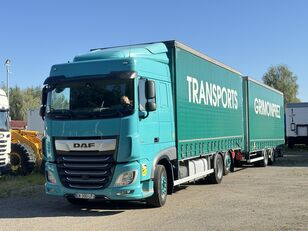

In [58]:
images_folder_path = Path(project_root, "images")
ref_image_path = Path(images_folder_path, "image_000053.jpeg")
query_image_path = Path(images_folder_path, "image_000054.jpeg")

ref_img = Image.open(ref_image_path)
query_img = Image.open(query_image_path)
ref_img

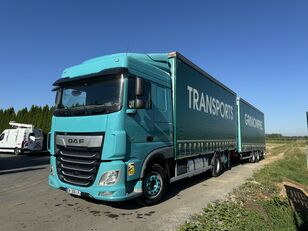

In [59]:
query_img

In [53]:
model = ResNet50_ReID(num_vehicles=NUM_VEHICLES, pretrained=True)
model.load_state_dict(cp['model_state_dict'])

model = model.to(device)



  ── 1:1 Verification ──
  Similarity matrix: [[0.8634166]]
    Accuracy      : 1.0000  (seuil=0.8650)
    TPR (Recall)  : 0.0000  |  FPR : 0.0000
    TP=0 TN=1 FP=0 FN=0
    Latence       : 6.65 ms/query
{'accuracy': np.float64(1.0), 'threshold': np.float64(0.865), 'tpr': 0.0, 'fpr': np.float64(0.0), 'latency_ms': 6.65}
Reference Image : image_000053.jpeg
Query Image     : image_000054.jpeg
Reference Embedding : torch.Size([1, 2048])
Query Embedding     : torch.Size([1, 2048])
Reference Norm      : 1.0000
Query Norm          : 1.0000


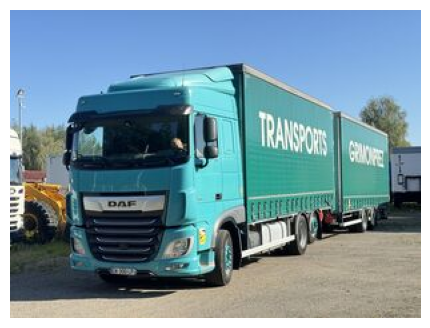

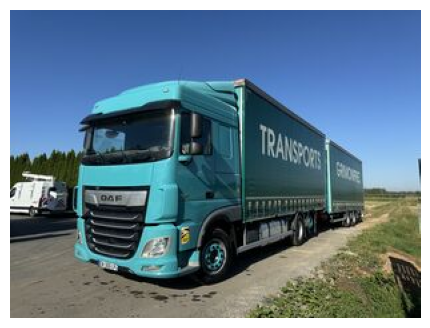

In [60]:
IMG_SIZE = (256, 256)

eval_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
model.eval()

ref_input_tensor = eval_tf(ref_img).unsqueeze(0).to(device)
query_input_tensor = eval_tf(query_img).unsqueeze(0).to(device)

with torch.no_grad():
    ref_embedding, _ = model(ref_input_tensor)
    query_embedding, _ = model(query_input_tensor)
    # probabilities = torch.softmax(logits, dim=1)
    # top_probs, top_classes = torch.topk(probabilities, k=5, dim=1)

ref_embedding = F.normalize(ref_embedding, dim=1)
query_embedding = F.normalize(query_embedding, dim=1)

verif = evaluate_verification(ref_embedding.cpu(), ['ref'], query_embedding.cpu(), ['query'])
print(verif)

print(f"Reference Image : {ref_image_path.name}")
print(f"Query Image     : {query_image_path.name}")
print(f"Reference Embedding : {ref_embedding.shape}")
print(f"Query Embedding     : {query_embedding.shape}")
print(f"Reference Norm      : {ref_embedding.norm(dim=1).item():.4f}")
print(f"Query Norm          : {query_embedding.norm(dim=1).item():.4f}")

plt.figure(figsize=(6, 4))
plt.imshow(ref_img)
plt.axis("off")
plt.figure(figsize=(6, 4))
plt.imshow(query_img)
plt.axis("off")
plt.show()

In [47]:
def extract_features(model, dataloader, device):
    """Extrait les embeddings pour toutes les images d'un dataloader."""
    model.eval()
    all_features, all_ids, all_names = [], [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extract'):
            images = batch['image'].to(device)
            features, _ = model(images)
            all_features.append(features.cpu())
            all_ids.extend(batch['vehicle_id'])
            all_names.extend(batch['image_name'])
    return torch.cat(all_features, dim=0), all_ids, all_names


def evaluate_verification(q_feat, q_ids, g_feat, g_ids):
    """Protocole 1:1 Verification."""
    print('\n  ── 1:1 Verification ──')
    t0 = time.perf_counter()
    
    q_feat = F.normalize(q_feat, dim=1)
    g_feat = F.normalize(g_feat, dim=1)
    sim_matrix = torch.mm(q_feat, g_feat.T).numpy()
    print(f'  Similarity matrix: {sim_matrix}')    

    # Generer toutes les paires et trouver le seuil optimal
    labels = np.array([[1 if q_ids[i] == g_ids[j] else 0 for j in range(len(g_ids))]
                       for i in range(len(q_ids))]).ravel()
    sims = sim_matrix.ravel()

    best_acc, best_th = 0.0, 0.5
    for th in np.linspace(0.0, 1.0, 201):
        acc = ((sims >= th).astype(int) == labels).mean()
        if acc > best_acc:
            best_acc, best_th = acc, th

    preds = (sims >= best_th).astype(int)
    tp = ((preds == 1) & (labels == 1)).sum()
    tn = ((preds == 0) & (labels == 0)).sum()
    fp = ((preds == 1) & (labels == 0)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    latency = (time.perf_counter() - t0) / len(q_ids) * 1000

    print(f'    Accuracy      : {best_acc:.4f}  (seuil={best_th:.4f})')
    print(f'    TPR (Recall)  : {tpr:.4f}  |  FPR : {fpr_val:.4f}')
    print(f'    TP={tp} TN={tn} FP={fp} FN={fn}')
    print(f'    Latence       : {latency:.2f} ms/query')
    return {'accuracy': round(best_acc,4), 'threshold': round(best_th,4),
            'tpr': round(tpr,4), 'fpr': round(fpr_val,4), 'latency_ms': round(latency,2)}

def evaluate_full(model, query_loader, gallery_loader, device):
    """Evaluation complete."""
    print('\n' + '='*60)
    print('  EXTRACTION DES EMBEDDINGS')
    print('='*60)

    t_q = time.perf_counter()
    q_feat, q_ids, _ = extract_features(model, query_loader, device)
    t_q_end = time.perf_counter()

    t_g = time.perf_counter()
    g_feat, g_ids, _ = extract_features(model, gallery_loader, device)
    t_g_end = time.perf_counter()

    print(f'  Queries: {len(q_ids)}  |  Gallery: {len(g_ids)}')
    print(f'  Temps queries : {t_q_end-t_q:.1f}s')
    print(f'  Temps gallery  : {t_g_end-t_g:.1f}s (NON compte dans latence)')

    # Verification 1:1
    v = evaluate_verification(q_feat, q_ids, g_feat, g_ids)
    
    recap = {
        'dataset': 'VeRi',
        'method': 'ResNet-50 ReID Baseline',
        'num_queries': len(q_ids),
        'gallery_size': len(g_ids),
        'verification_1to1': v
    }
    return recap


# # ── Lancer l'evaluation ──
# print('\n' + '='*60)
# print('  EVALUATION SUR LE TEST SET')
# print('='*60)
# report = evaluate_full(model, query_loader, test_loader, device)

---
##  Résumé

### Résultats attendus (apres 60 epochs) :

| Protocole | Métrique | Valeur attendue |
|-----------|----------|-----------------|
| 1:1 Verification | Accuracy | ~0.75-0.80 |
| 1:N Identification | Rank-1 | ~83-88% |
| 1:N Identification | Rank-5 | ~92-95% |
| Latence | ms/query | < 1 ms (GPU) |

### Benchmark etat de l'art sur VeRi :

| Methode | mAP | Rank-1 |
|---------|-----|--------|
| **ResNet-50 (ce notebook)** | ~53% | ~83-88% |
| TransReID (CVPR'22) | 82.3% | 97.1% |
| MART (AAAI'21) | 82.7% | 97.6% |
| TVRVI (article etudie) | 84.7% | 97.8% |

### Prochaines etapes possibles :
1. Télécharger le `.zip` depuis Kaggle (Output → Download)
2. Implémenter TransReID pour passer de ~53% à ~82% mAP
3. Ajouter l'annotation des vues pour TVRVI (84.7% mAP)